# Jaccard vs PageRank Comparison

Jacob Lehman and Trevor Schmuckley, CSCI 4022 Final Project

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

DATA_DIR = Path("data")

## Load both result CSVs

In [2]:
jaccard = pd.read_csv(DATA_DIR / "jaccard_k3_results.csv")
pagerank = pd.read_csv(DATA_DIR / "pagerank_results.csv")

print(f"Jaccard rows:  {len(jaccard):>7,}")
print(f"PageRank rows: {len(pagerank):>7,}")

Jaccard rows:  199,941
PageRank rows: 199,941


## Inner join on (path_id, step)

In [3]:
joined = jaccard.merge(
    pagerank[["path_id", "step", "pagerank_prediction", "correct", "actual_rank"]],
    on=["path_id", "step"],
    suffixes=("_jaccard", "_pagerank"),
)

joined.to_csv(DATA_DIR / "comparison_results.csv", index=False)
print(f"Joined rows: {len(joined):,}")
joined.head()

Joined rows: 199,941


,path_id,step,path_length,current_page,target_page,actual_next_page,jaccard_prediction,correct_jaccard,actual_rank_jaccard,num_candidates,pagerank_prediction,correct_pagerank,actual_rank_pagerank
0,0,0,8,14th_century,African_slave_trade,15th_century,13th_century,False,27,31,France,False,13
1,0,1,8,15th_century,African_slave_trade,16th_century,20th_century,False,51,57,France,False,15
2,0,2,8,16th_century,African_slave_trade,Pacific_Ocean,Pacific_Ocean,True,1,91,France,False,21
3,0,3,8,Pacific_Ocean,African_slave_trade,Atlantic_Ocean,Marshall_Islands,False,57,87,United_States,False,19
4,0,4,8,Atlantic_Ocean,African_slave_trade,Accra,Rockall,False,59,125,United_States,False,117


## Headline numbers

In [4]:
print("Top-1 match rate:")
print(f"  Jaccard:  {joined['correct_jaccard'].mean():.4f}")
print(f"  PageRank: {joined['correct_pagerank'].mean():.4f}")

print("\nAverage actual rank:")
print(f"  Jaccard:  {joined['actual_rank_jaccard'].mean():.2f}")
print(f"  PageRank: {joined['actual_rank_pagerank'].mean():.2f}")

Top-1 match rate:
  Jaccard:  0.2545
  PageRank: 0.0728

Average actual rank:
  Jaccard:  23.56
  PageRank: 27.59


## Agreement breakdown

In [5]:
j = joined["correct_jaccard"]
p = joined["correct_pagerank"]

agreement = pd.Series(
    {
        "Both right":      ( j &  p).sum(),
        "Jaccard only":    ( j & ~p).sum(),
        "PageRank only":   (~j &  p).sum(),
        "Both wrong":      (~j & ~p).sum(),
    },
    name="count",
).to_frame()
agreement["fraction"] = agreement["count"] / agreement["count"].sum()
agreement

,count,fraction
Both right,1396,0.006982
Jaccard only,49491,0.247528
PageRank only,13152,0.065779
Both wrong,135902,0.679711


## Top-1 accuracy bar chart

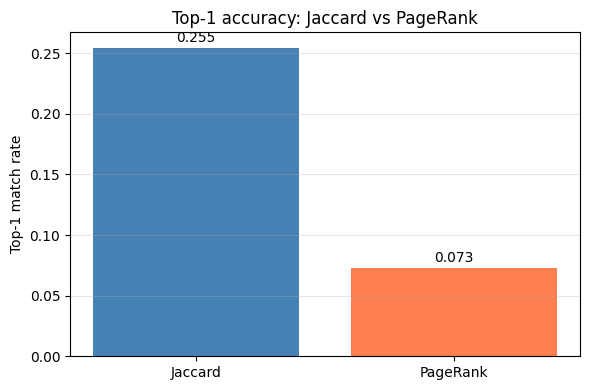

In [6]:
top1 = [joined["correct_jaccard"].mean(), joined["correct_pagerank"].mean()]

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(["Jaccard", "PageRank"], top1, color=["steelblue", "coral"])
for bar, value in zip(bars, top1):
    ax.text(bar.get_x() + bar.get_width() / 2, value + 0.005, f"{value:.3f}", ha="center")
ax.set_ylabel("Top-1 match rate")
ax.set_title("Top-1 accuracy: Jaccard vs PageRank")
ax.grid(True, alpha=0.3, axis="y")
fig.tight_layout()
fig.savefig("comparison_top1.png", dpi=150)
plt.show()

## Top-1 by path length

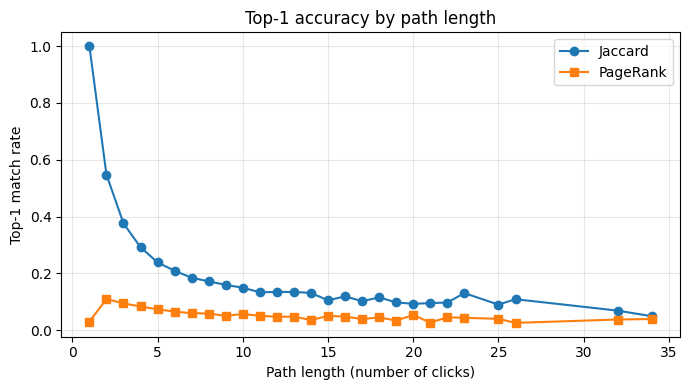

In [7]:
by_length = (
    joined.groupby("path_length")
    .agg(
        jaccard=("correct_jaccard", "mean"),
        pagerank=("correct_pagerank", "mean"),
        n=("path_id", "size"),
    )
    .reset_index()
)
by_length = by_length[by_length["n"] >= 100]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(by_length["path_length"], by_length["jaccard"], marker="o", label="Jaccard")
ax.plot(by_length["path_length"], by_length["pagerank"], marker="s", label="PageRank")
ax.set_xlabel("Path length (number of clicks)")
ax.set_ylabel("Top-1 match rate")
ax.set_title("Top-1 accuracy by path length")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig("comparison_by_path_length.png", dpi=150)
plt.show()

## Top-1 by number of candidates

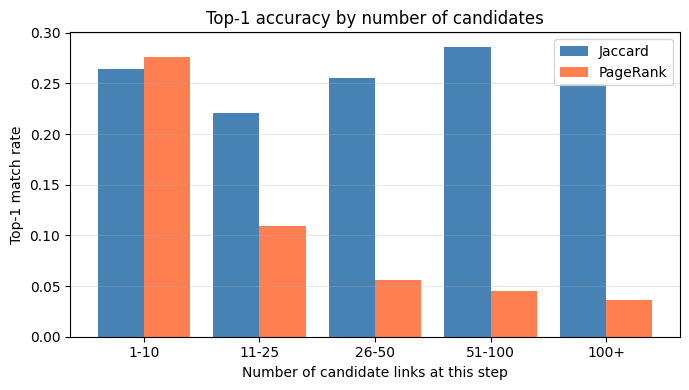

In [8]:
candidate_bins = pd.cut(
    joined["num_candidates"],
    bins=[0, 10, 25, 50, 100, joined["num_candidates"].max() + 1],
    labels=["1-10", "11-25", "26-50", "51-100", "100+"],
)
by_candidates = (
    joined.assign(bucket=candidate_bins)
    .groupby("bucket", observed=True)
    .agg(
        jaccard=("correct_jaccard", "mean"),
        pagerank=("correct_pagerank", "mean"),
    )
    .reset_index()
)

x = range(len(by_candidates))
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar([i - 0.2 for i in x], by_candidates["jaccard"], width=0.4, label="Jaccard", color="steelblue")
ax.bar([i + 0.2 for i in x], by_candidates["pagerank"], width=0.4, label="PageRank", color="coral")
ax.set_xticks(list(x))
ax.set_xticklabels(by_candidates["bucket"].astype(str))
ax.set_xlabel("Number of candidate links at this step")
ax.set_ylabel("Top-1 match rate")
ax.set_title("Top-1 accuracy by number of candidates")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")
fig.tight_layout()
fig.savefig("comparison_by_num_candidates.png", dpi=150)
plt.show()